# Used Car Price Prediction Model 

This notebook contains the end-to-end Machine Learning pipeline to predict used car prices, built as part of my internship project. We use Python, Pandas, Scikit-learn, and Seaborn/Matplotlib for the workflow.

## Step 1: Imports and Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure plots directory exists
os.makedirs('plots', exist_ok=True)

# Inline plotting for Jupyter
%matplotlib inline

## Step 2: Data Loading

In [2]:
df = pd.read_csv('car_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 3: Feature Engineering
We calculate the age of the car (depreciation proxy) and create brand goodwill tiers based on value retention.

In [3]:
# Feature 1: Car Age (Current Year 2026 - Manufacturing Year)
CURRENT_YEAR = 2026
df['Car_Age'] = CURRENT_YEAR - df['Year']

# Feature 2: Brand Goodwill Tiering
def get_brand(car_name):
    name = car_name.lower().strip()
    if any(x in name for x in ['fortuner', 'innova', 'corolla', 'etios', 'camry', 'land cruiser']):
        return 'Toyota'
    elif any(x in name for x in ['brio', 'amaze', 'city', 'jazz', 'accord', 'civic']):
        return 'Honda'
    elif any(x in name for x in ['i10', 'i20', 'eon', 'xcent', 'elantra', 'creta', 'verna', 'grand i10']):
        return 'Hyundai'
    elif any(x in name for x in ['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza', 's cross', 'alto', 'ertiga', 'dzire', 'ignis', 'baleno', 'omni', '800']):
        return 'Maruti Suzuki'
    else:
        return 'Other'

df['Brand'] = df['Car_Name'].apply(get_brand)

def get_goodwill_tier(brand):
    if brand in ['Toyota', 'Honda']:
        return 'High_Goodwill'
    elif brand == 'Hyundai':
        return 'Medium_Goodwill'
    else:
        return 'Budget_Goodwill'

df['Brand_Goodwill'] = df['Brand'].apply(get_goodwill_tier)

print("Brand Goodwill Tier counts:")
print(df['Brand_Goodwill'].value_counts())

Brand Goodwill Tier counts:
Brand_Goodwill
Budget_Goodwill    151
High_Goodwill      100
Medium_Goodwill     50
Name: count, dtype: int64


## Step 4: Data Preprocessing
We handle categorical variables with dummy encoding and split the dataset into train and test sets.

In [4]:
# Drop original categorical/redundant columns
model_df = df.drop(columns=['Car_Name', 'Brand', 'Year'])

# One-hot encode categorical features
model_df = pd.get_dummies(model_df, columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand_Goodwill'], drop_first=True)

# Convert boolean to 0/1
bool_cols = model_df.select_dtypes(include=['bool']).columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

# X/y Split
X = model_df.drop(columns=['Selling_Price'])
y = model_df['Selling_Price']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 240
Testing set size: 61


## Step 5: Model Training & Evaluation
We compare a baseline Linear Regression model against a Random Forest Regressor.

In [5]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"[{name}] R2: {r2:.4f} | MAE: {mae:.4f} Lakhs | RMSE: {rmse:.4f} Lakhs")
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

print("--- Linear Regression ---")
lr_metrics = evaluate(y_test, y_pred_lr, "Linear Regression")

print("\n--- Random Forest ---")
rf_metrics = evaluate(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
[Linear Regression] R2: 0.8469 | MAE: 1.2194 Lakhs | RMSE: 1.8782 Lakhs

--- Random Forest ---
[Random Forest] R2: 0.9624 | MAE: 0.6208 Lakhs | RMSE: 0.9305 Lakhs


## Step 6: Data Visualization

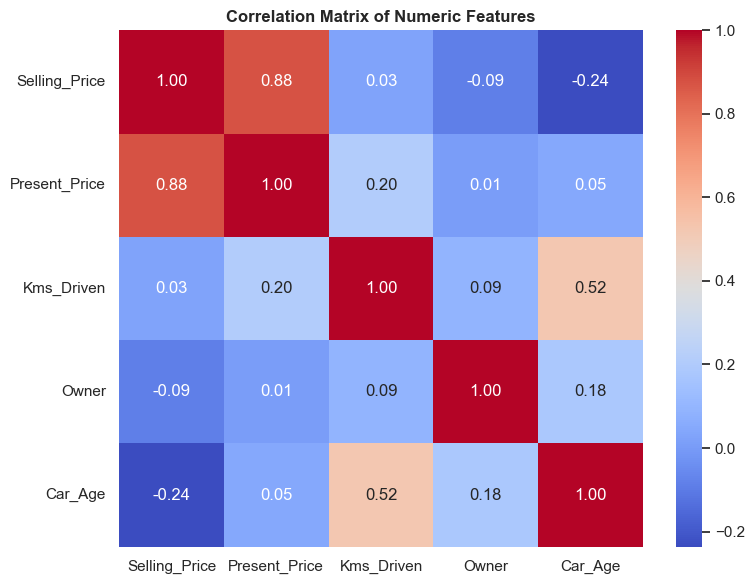

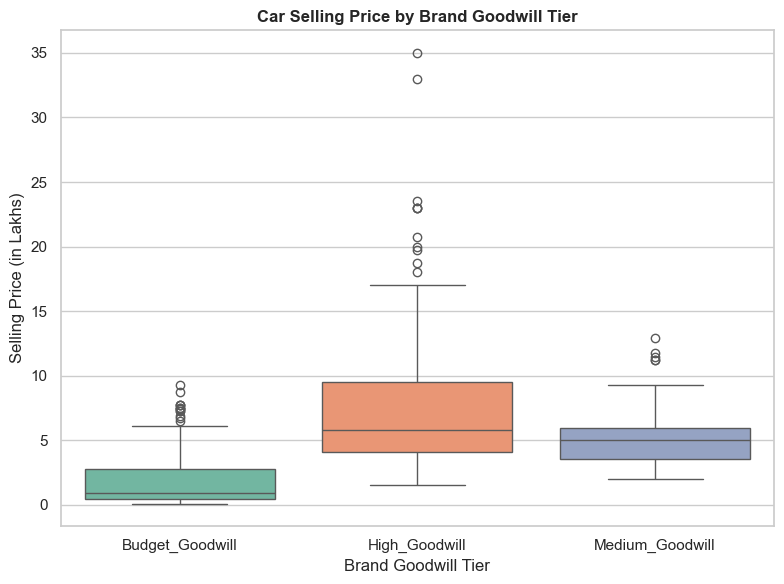

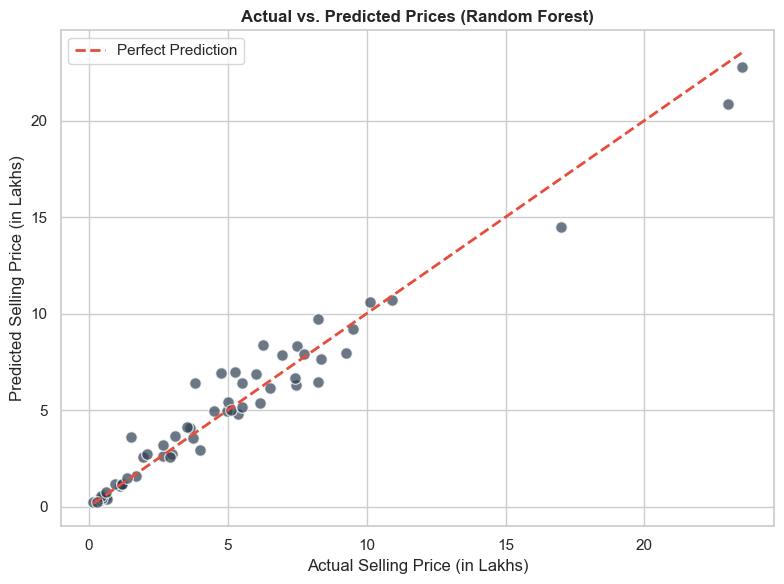

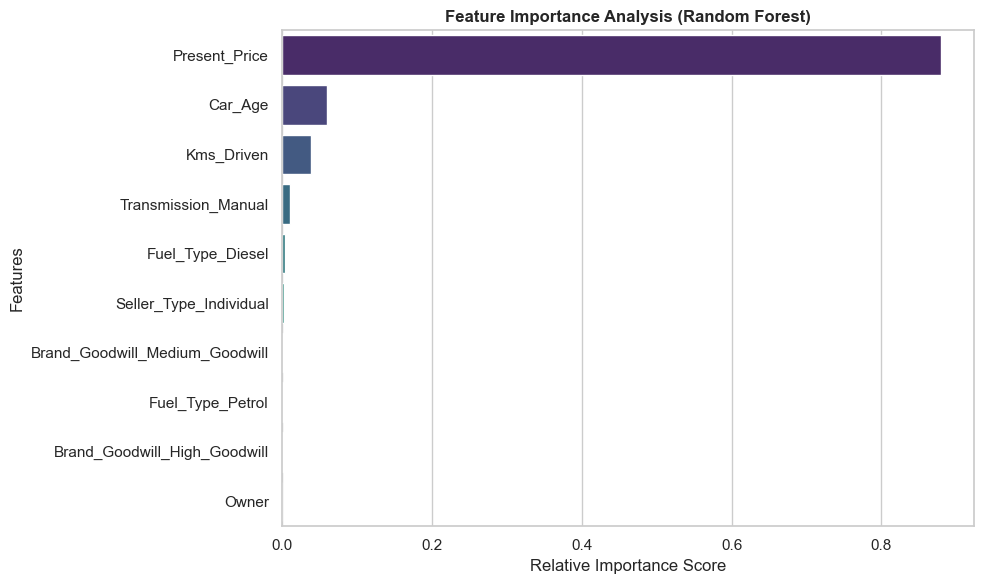

In [6]:
sns.set_theme(style="whitegrid")

# Plot 1: Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).copy()
numeric_cols['Car_Age'] = df['Car_Age']
if 'Year' in numeric_cols.columns:
    numeric_cols = numeric_cols.drop(columns=['Year'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features", fontweight='bold')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=300)
plt.show()

# Plot 2: Brand Goodwill Pricing Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Brand_Goodwill', y='Selling_Price', data=df, hue='Brand_Goodwill', palette='Set2', legend=False)
plt.title("Car Selling Price by Brand Goodwill Tier", fontweight='bold')
plt.xlabel("Brand Goodwill Tier")
plt.ylabel("Selling Price (in Lakhs)")
plt.tight_layout()
plt.savefig('plots/brand_price_distribution.png', dpi=300)
plt.show()

# Plot 3: Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
best_y_pred = y_pred_rf if rf_metrics["R2"] > lr_metrics["R2"] else y_pred_lr
best_model_name = "Random Forest" if rf_metrics["R2"] > lr_metrics["R2"] else "Linear Regression"
plt.scatter(y_test, best_y_pred, alpha=0.7, color='#2c3e50', edgecolors='w', s=70)
min_val, max_val = min(min(y_test), min(best_y_pred)), max(max(y_test), max(best_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='#e74c3c', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title(f"Actual vs. Predicted Prices ({best_model_name})", fontweight='bold')
plt.xlabel("Actual Selling Price (in Lakhs)")
plt.ylabel("Predicted Selling Price (in Lakhs)")
plt.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=300)
plt.show()

# Plot 4: Feature Importance
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis', hue=feature_names[indices], legend=False)
plt.title("Feature Importance Analysis (Random Forest)", fontweight='bold')
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=300)
plt.show()